In [ ]:
pip install pandas numpy matplotlib yfinance statsmodels

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

In [3]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 50.4 MB/s eta 0:00:00


**Fetch the closing price data from Yahoo Finance**.

Time interval: Daily

Year range: 2018 - 2026





In [5]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2018-01-01", interval="1d")
btc = btc[['Close']]
btc.dropna(inplace=True)


/tmp/ipykernel_5063/3420808766.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2018-01-01", interval="1d")
[*********************100%***********************]  1 of 1 completed


**Plot the price alongside with its moving average**

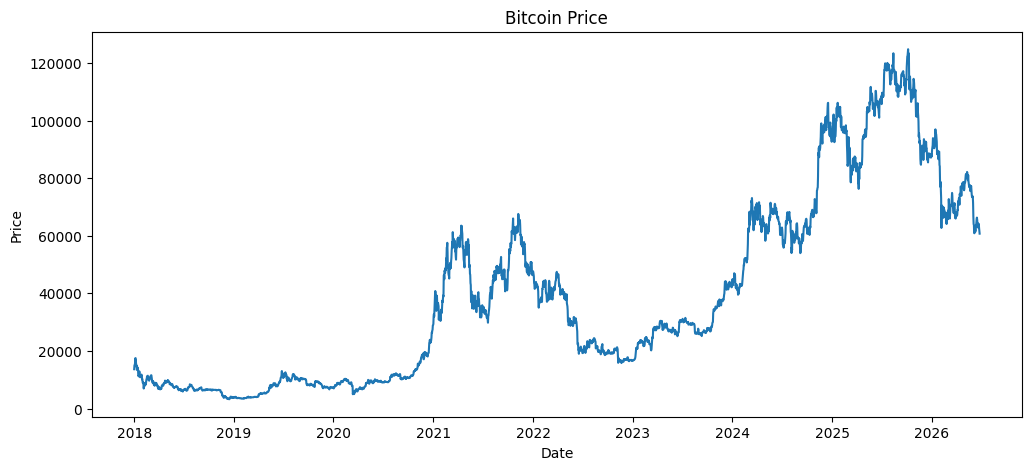

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Close"], label="Close Price")
plt.title("Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

**Plotting the moving average**

Here, I plot for both weekly and monthly moving averages. It is visible that the higher the time window, the smoother also the graph.

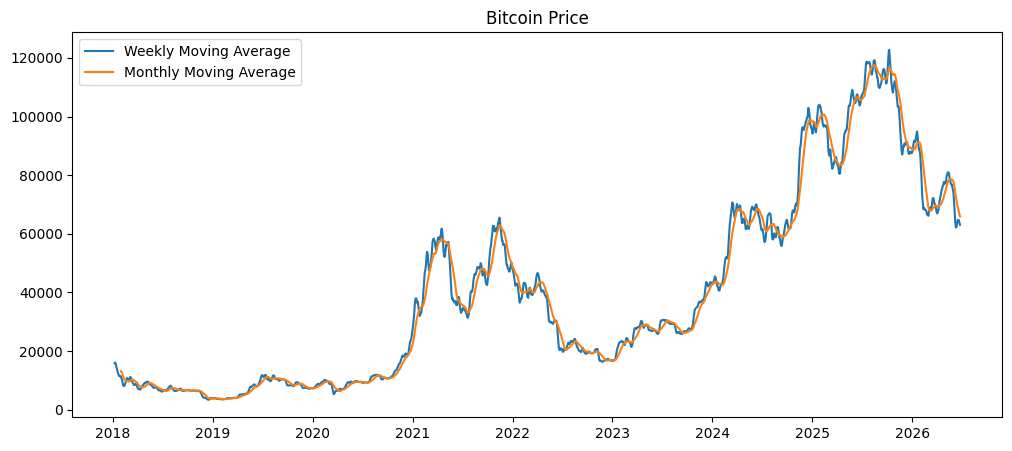

In [4]:
btc['Weekly Moving Average'] = btc['Close'].rolling(window=7).mean()
btc['Monthly Moving Average'] = btc['Close'].rolling(window=30).mean()
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc['Weekly Moving Average'], label = "Weekly Moving Average")
plt.plot(btc['Monthly Moving Average'], label = "Monthly Moving Average")
plt.legend()
plt.title("Bitcoin Price")
plt.show()

In [148]:
btc

Price,Close,Weekly Moving Average,Monthly Moving Average
Ticker,BTC-USD,,
Date,,,
2018-01-01,13657.200195,NaN,NaN
2018-01-02,14982.099609,NaN,NaN
2018-01-03,15201.000000,NaN,NaN
2018-01-04,15599.200195,NaN,NaN
2018-01-05,17429.500000,NaN,NaN
...,...,...,...
2026-06-20,64239.675781,64670.852679,67737.029427
2026-06-21,63237.539062,64317.587054,67328.672656


**Plot returns**

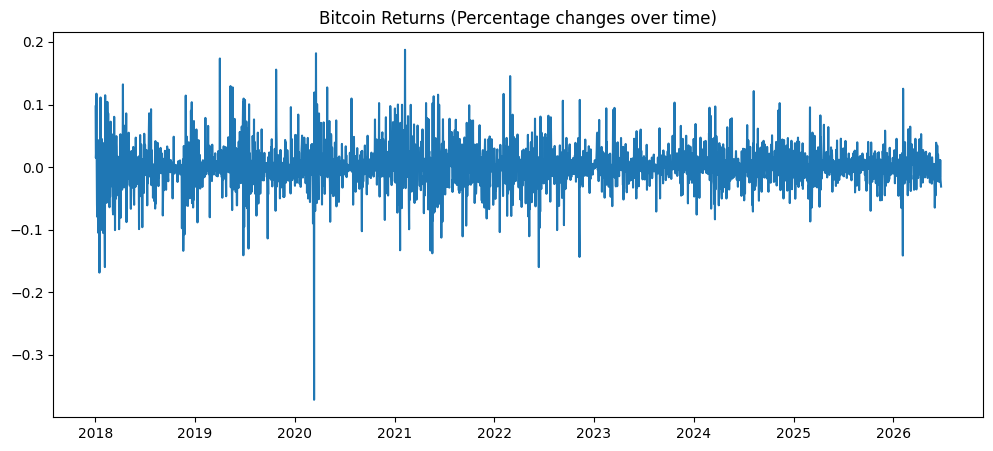

In [5]:
btc["Returns"] = btc["Close"].pct_change()
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Returns"])
plt.title("Bitcoin Returns (Percentage changes over time)")
plt.show()

**Rolling statistics plot (standard deviation)**

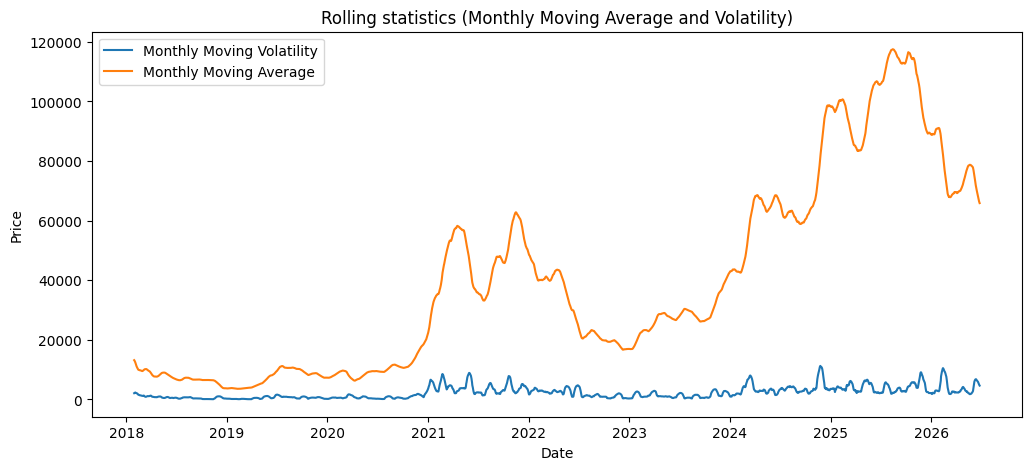

In [6]:
btc["Monthly Moving Volatility"] = btc["Close"].rolling(window=30).std()
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Monthly Moving Volatility"], label = "Monthly Moving Volatility")
plt.plot(btc.index, btc["Monthly Moving Average"], label = "Monthly Moving Average")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Rolling statistics (Monthly Moving Average and Volatility)")
plt.show()

In [9]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(btc["Close"].dropna())
print(result[1]) #p-value

0.6290968554208781


In [10]:
#Train/test split
split = int(len(btc) * 0.8)
train = btc[:split]
test = btc[split:]


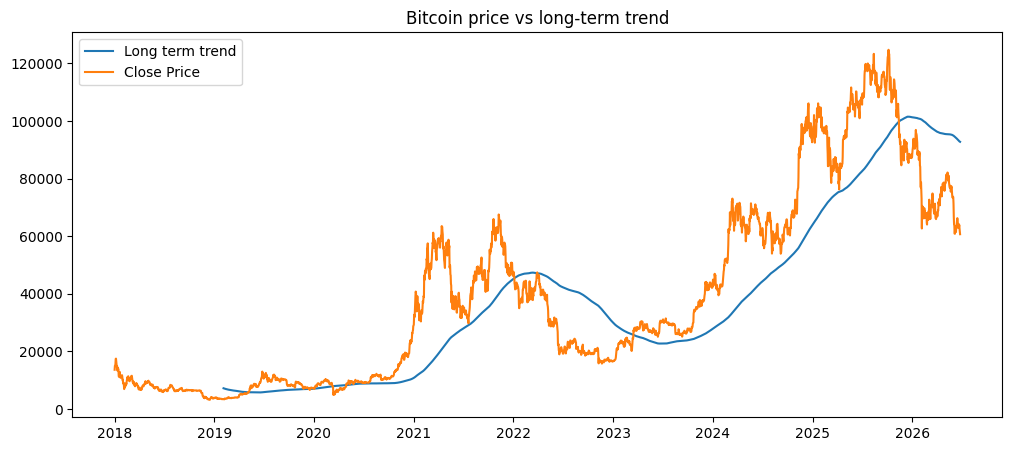

In [12]:
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Long term trend"], label = "Long term trend")
plt.plot(btc.index, btc["Close"], label = "Close Price")
plt.title("Bitcoin price vs long-term trend")
plt.legend()
plt.show()

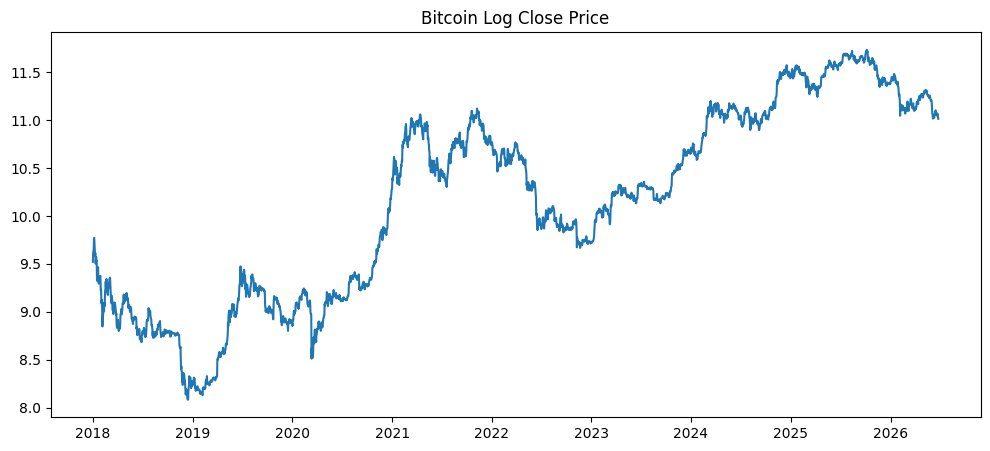

In [13]:
#Log transformation
import numpy as np
btc["Log_Close"] = np.log(btc["Close"])
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Log_Close"])
plt.title("Bitcoin Log Close Price")
plt.show()

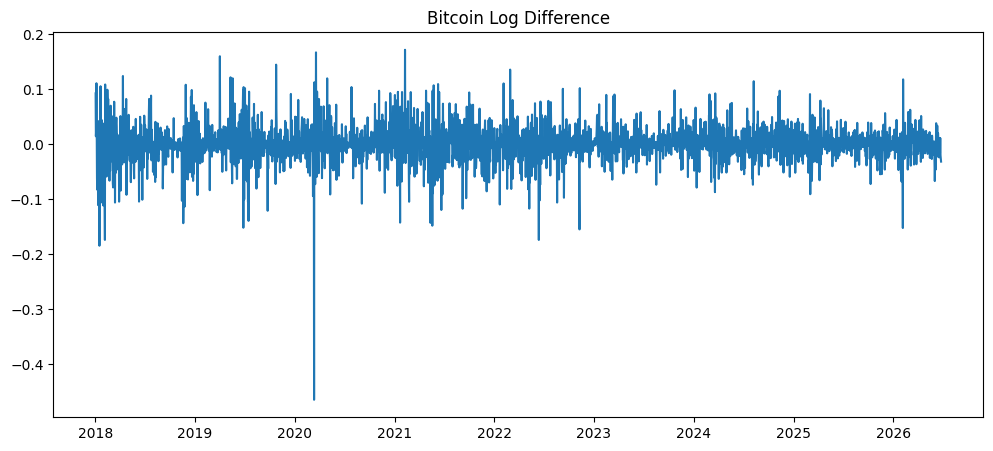

In [15]:
#Differencing the log-transformed price
btc["Log_diff"] = btc["Log_Close"].diff()
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Log_diff"])
plt.title("Bitcoin Log Difference")
plt.show()

In [21]:
#Apply adfuller test to the differented log price
print(f"{adfuller(btc["Log_diff"].dropna())[1]:10f}")

  0.000000


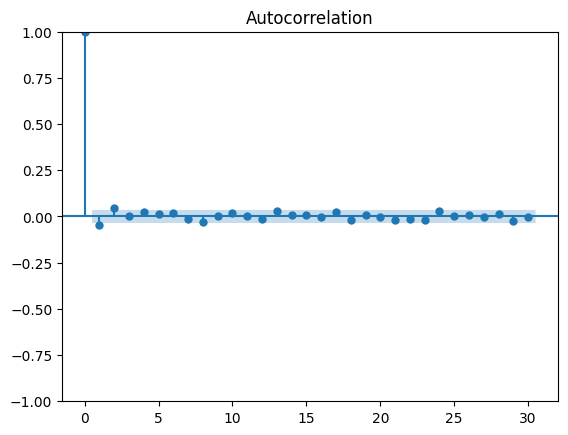

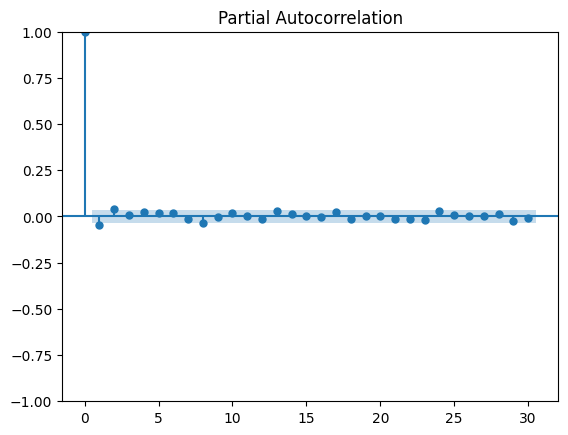

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
log_return = np.log(btc["Close"]).diff().dropna()
plot_acf(log_return, lags = 30)
plot_pacf(log_return, lags = 30)
plt.show()


In [7]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(log_return, order=(1,0,1))
result = model.fit()

print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 3098
Model:                 ARIMA(1, 0, 1)   Log Likelihood                6099.696
Date:                Fri, 26 Jun 2026   AIC                         -12191.392
Time:                        06:42:31   BIC                         -12167.238
Sample:                    01-02-2018   HQIC                        -12182.718
                         - 06-26-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.779      0.436      -0.001       0.002
ar.L1         -0.4517      0.207     -2.181      0.029      -0.858      -0.046
ma.L1          0.3997      0.212      1.889      0.0

In [9]:
from arch import arch_model
model_garch = arch_model(log_return * 10, mean='ARX', lags=1, vol='Garch', p=1, q=1, dist = 't')
res = model_garch.fit()
print(res.summary())

Iteration:      1,   Func. Count:      8,   Neg. LLF: 107459.31446051518
Iteration:      2,   Func. Count:     20,   Neg. LLF: 71329.64757754859
Iteration:      3,   Func. Count:     30,   Neg. LLF: 22527.215204080167
Iteration:      4,   Func. Count:     39,   Neg. LLF: 4179.149698806846
Iteration:      5,   Func. Count:     48,   Neg. LLF: 2680.7609358152795
Iteration:      6,   Func. Count:     56,   Neg. LLF: 2428.591898233873
Iteration:      7,   Func. Count:     64,   Neg. LLF: 2115.143672777769
Iteration:      8,   Func. Count:     72,   Neg. LLF: 449.61218297656194
Iteration:      9,   Func. Count:     79,   Neg. LLF: 2202.301192889475
Iteration:     10,   Func. Count:     87,   Neg. LLF: 967.7534884102172
Iteration:     11,   Func. Count:     98,   Neg. LLF: 445.3904912312506
Iteration:     12,   Func. Count:    105,   Neg. LLF: 499.30971383322304
Iteration:     13,   Func. Count:    114,   Neg. LLF: 444.7871684801257
Iteration:     14,   Func. Count:    121,   Neg. LLF: 444.6

In [70]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

acorr_ljungbox(res.std_resid, lags=[10], return_df=True)
het_arch(res.std_resid.dropna())

(np.float64(4.6197850504066915),
 np.float64(0.9150885985210435),
 0.4607819694241423,
 0.9156053251186883)

**TRAIN TEST SPLIT**

In [145]:
train_size = int(len(btc) * 0.8)
train = log_return[:train_size]
test = log_return[train_size:]
print(len(train), len(test))

2479 619


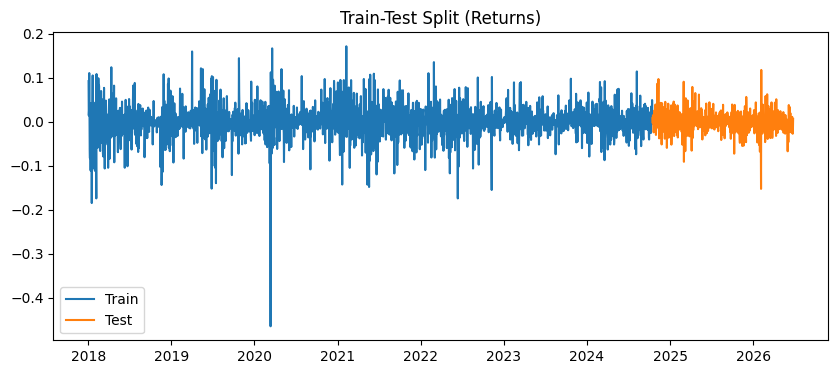

In [12]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.legend()
plt.title('Train-Test Split (Returns)')
plt.show()

In [45]:
model = arch_model(train * 100, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist = 't')
res = model.fit()
print(res.summary())

Iteration:      1,   Func. Count:      8,   Neg. LLF: 56908.12400812848
Iteration:      2,   Func. Count:     17,   Neg. LLF: 60752.455347424286
Iteration:      3,   Func. Count:     27,   Neg. LLF: 48579.673567457765
Iteration:      4,   Func. Count:     36,   Neg. LLF: 8886.578574697447
Iteration:      5,   Func. Count:     45,   Neg. LLF: 7911.136298505946
Iteration:      6,   Func. Count:     53,   Neg. LLF: 7669.149462433171
Iteration:      7,   Func. Count:     61,   Neg. LLF: 6675.715381816061
Iteration:      8,   Func. Count:     69,   Neg. LLF: 6244.980530528178
Iteration:      9,   Func. Count:     76,   Neg. LLF: 7331.178407556537
Iteration:     10,   Func. Count:     84,   Neg. LLF: 13353.102130266545
Iteration:     11,   Func. Count:     93,   Neg. LLF: 7950.318709143946
Iteration:     12,   Func. Count:    101,   Neg. LLF: 6215.990636918955
Iteration:     13,   Func. Count:    108,   Neg. LLF: 6213.326817278534
Iteration:     14,   Func. Count:    115,   Neg. LLF: 6212.96

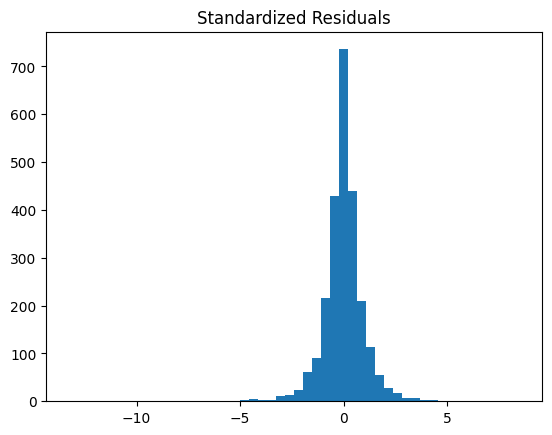

In [51]:
standard_resid = res.std_resid
plt.hist(standard_resid, bins = 50)
plt.title("Standardized Residuals")
plt.show()

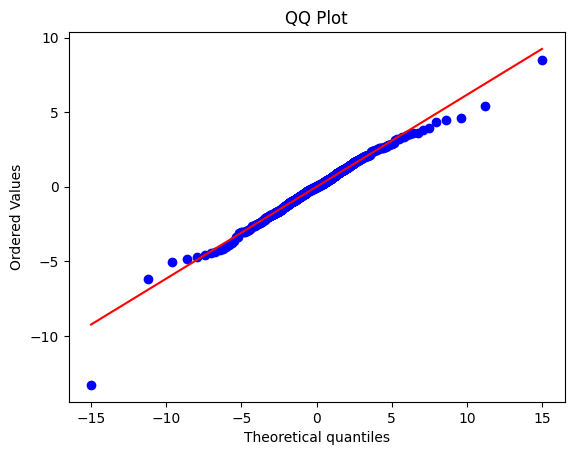

In [48]:
import scipy.stats as stats

stats.probplot(clean_resid, dist="t", sparams=(res.params['nu'],), plot=plt)
plt.title("QQ Plot")
plt.show()

In [47]:
from statsmodels.stats.diagnostic import acorr_ljungbox
clean_resid = standard_resid.replace([np.inf, -np.inf], np.nan).dropna()
lb_resid = acorr_ljungbox(clean_resid**2, lags=[10, 20], return_df=True)
print(lb_resid)

     lb_stat  lb_pvalue
10  4.567036   0.918164
20  7.855300   0.992783


In [44]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(clean_resid.dropna())
print("LM Stat:", arch_test[0])
print("p-value:", arch_test[1])

LM Stat: 4.6197850504066915
p-value: 0.9150885985210435


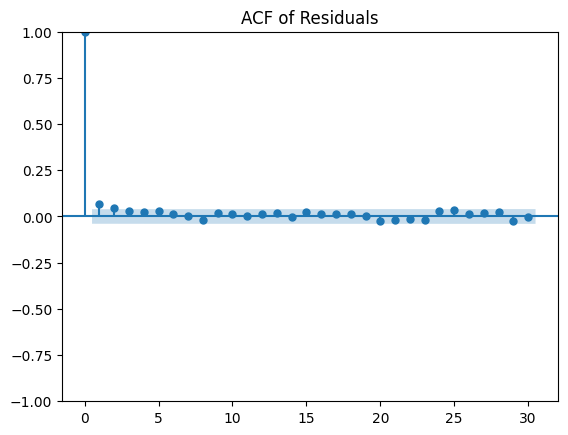

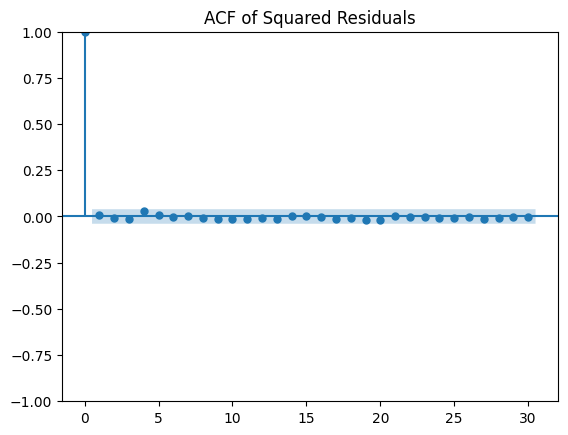

In [49]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(clean_resid, lags=30)
plt.title("ACF of Residuals")
plt.show()

plot_acf(clean_resid**2, lags=30)
plt.title("ACF of Squared Residuals")
plt.show()

**Forecasting using train-test model**

In [75]:
model = arch_model(train * 100, vol = "GARCH", lags = 1, p = 1, q = 1, dist = 't').fit(disp = 'off')
print(model.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      BTC-USD   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6221.82
Distribution:      Standardized Student's t   AIC:                           12453.6
Method:                  Maximum Likelihood   BIC:                           12482.7
                                              No. Observations:                 2479
Date:                      Fri, Jun 26 2026   Df Residuals:                     2478
Time:                              08:20:22   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [199]:
forecasts = []
actuals = []

history = train * 10 #Scaling to x10

for t in range(len(test)):
    model = arch_model(history, vol='EGARCH', lags = 1, p=1, o = 1, q=1, dist='t')
    res = model.fit(disp='off')

    # 1-step ahead forecast
    fcast = res.forecast(horizon=1)
    var_forecast = fcast.variance.iloc[0, 0]
    forecasts.append(var_forecast)
    actuals.append((test.iloc[t]*10)**2)  # squared return as proxy

    # update history
    history = pd.concat([history, test.iloc[t:t+1] * 10])


In [192]:
type(history)

pandas.core.frame.DataFrame

In [173]:
res = arch_model(forecasts * 10, vol = "GARCH", lags = 1, p = 1, o = 1, q = 1, dist = 't').fit(disp = 'off')
print(res.params)

mu           0.547420
omega        0.001635
alpha[1]     1.000000
gamma[1]    -0.056664
beta[1]      0.028332
nu          14.283781
Name: params, dtype: float64


In [200]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
forecasts = np.array(forecasts)
actuals = np.array(actuals)

# MSE
mse = np.mean((forecasts - actuals) ** 2)

# MAE
mae = np.mean(np.abs(forecasts - actuals))

# QLIKE
qlike = np.mean(np.log(forecasts) + actuals / forecasts)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"QLIKE: {qlike}")


MSE: 0.02497641238411669
MAE: 0.0905858964227964
QLIKE: -1.7298167085868001


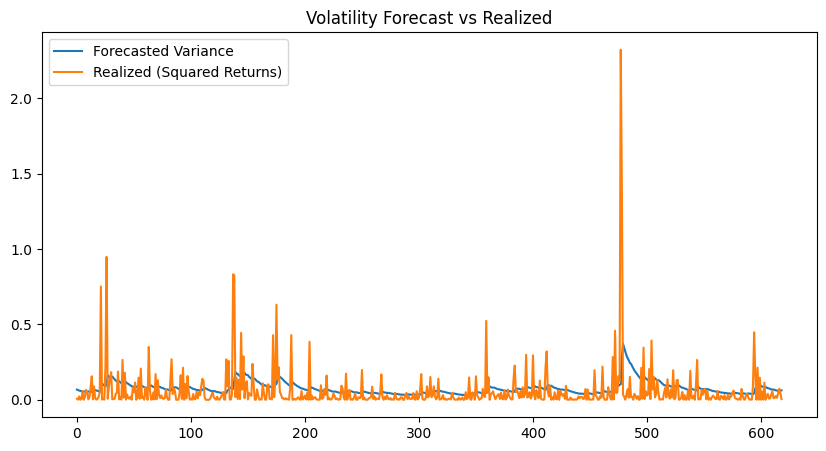

In [193]:
plt.figure(figsize=(10,5))
plt.plot(forecasts, label='Forecasted Variance')
plt.plot(actuals, label='Realized (Squared Returns)')
plt.legend()
plt.title("Volatility Forecast vs Realized")
plt.show()

In [201]:
import statsmodels.api as sm

X = sm.add_constant(forecasts)
y = actuals
model = sm.OLS(y,X).fit()
print(model.summary())
model.f_test("const = 0, x1 = 1")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     12.46
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           0.000448
Time:                        11:53:38   Log-Likelihood:                 316.61
No. Observations:                 619   AIC:                            -629.2
Df Residuals:                     617   BIC:                            -620.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0175      0.013      1.396      0.1

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=28.541126417917056, p=1.39651479908319e-12, df_denom=617, df_num=2>